1.Setup

In [116]:
# --- Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor 
from xgboost import XGBRegressor 
from catboost import CatBoostRegressor
from sklearn.svm import SVC

2. Load Dataset






In [117]:

df = pd.read_csv("Spotify_Song.csv")
df.head()

,Song_ID,Song_Name,Artist,Languages,Year,Genre,Languages.1,Danceability,Tempo,Energy,Popularity
0,1.0,Natarang,Ajay-Atul,Marathi,2010.0,Folk/Drama,Marathi,0.60,110.0,0.70,80.0
1,2.0,Kombdi Palali,Ajay-Atul,Marathi,2006.0,Folk/Drama,Marathi,0.75,120.0,0.85,78.0
2,3.0,Zingaat,Ajay-Atul,Marathi,2016.0,Dance,Marathi,0.90,130.0,0.88,95.0
3,4.0,Mala Jau Dya Na Ghari,Anand Shinde,Marathi,2008.0,Folk/Drama,Marathi,0.70,100.0,0.65,82.0
4,5.0,Hi Chaal Turu Turu,Ashok Patki,Marathi,1990.0,Pop,Marathi,0.68,95.0,0.60,75.0


3. Preprocessing

- Encode categorical features (genre, artist_name)
- Scale numerical features (danceability, energy, tempo, etc.)
- Define target (popularity_bin for classification OR popularity for         regression)


In [118]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load or create df first
df = pd.read_csv("Spotify_Song.csv")   # replace with your file

# Classification target
df["Tempo_bin"] = pd.cut(
    df["Tempo"], 
    bins=[0, 30, 60, 100], 
    labels=["Low", "Medium", "High"]
)

# Encode categorical
label_enc = LabelEncoder()
df["genre_encoded"] = label_enc.fit_transform(df["Tempo_bin"].astype(str))

# Features & target
X = df[["Danceability","Energy","Year","Tempo","Popularity","genre_encoded"]]
y = df["Tempo_bin"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

4. Model Training – Classification



HGB Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

        High       1.00      1.00      1.00         3

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



c:\Users\sejal\senv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


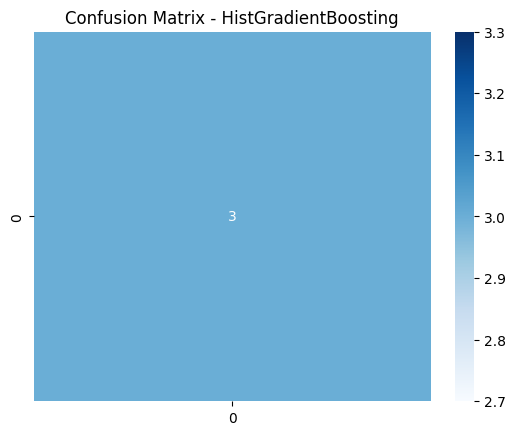

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         3

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



c:\Users\sejal\senv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


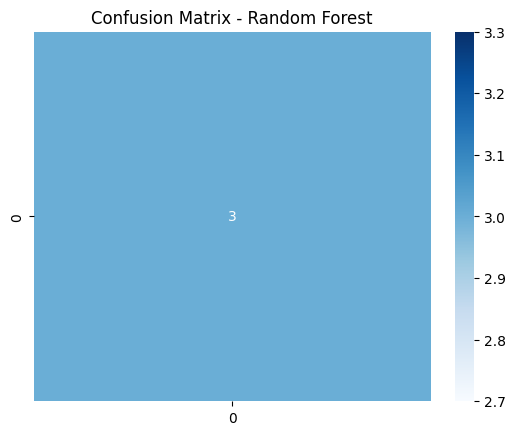

In [119]:
# HistGradientBoosting Classifier
hgb_clf = HistGradientBoostingClassifier(max_iter=200, random_state=42)

# Remove rows with NaN values before fitting
mask_train_clean = ~pd.isnull(y_train).values
X_train_hgb = X_train[mask_train_clean]
y_train_hgb = y_train[mask_train_clean]

mask_test_clean = ~pd.isnull(y_test).values
X_test_hgb = X_test[mask_test_clean]
y_test_hgb = y_test[mask_test_clean]

hgb_clf.fit(X_train_hgb, y_train_hgb)
y_pred_hgb = hgb_clf.predict(X_test_hgb)

print("HGB Accuracy:", accuracy_score(y_test_hgb, y_pred_hgb))
print("\nClassification Report:\n", classification_report(y_test_hgb, y_pred_hgb))

# Confusion Matrix for HGB
sns.heatmap(confusion_matrix(y_test_hgb, y_pred_hgb), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - HistGradientBoosting")
plt.show()

# Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(X_train_hgb, y_train_hgb)
y_pred_rf = rf_clf.predict(X_test_hgb)

print("Random Forest Accuracy:", accuracy_score(y_test_hgb, y_pred_rf))
print(classification_report(y_test_hgb, y_pred_rf))

# Confusion Matrix for Random Forest
sns.heatmap(confusion_matrix(y_test_hgb, y_pred_rf), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()


5. Model Training – Regression (optional)

In [120]:
# Predict popularity as numeric
X = df[["Danceability","Energy","Tempo","Year","genre_encoded"]]
y = df["Popularity"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
# remove rows with missing targets from train and test before fitting/predicting
mask_train = ~pd.isnull(y_train).values
X_train = X_train[mask_train]
y_train = y_train[mask_train]

mask_test = ~pd.isnull(y_test).values
X_test = X_test[mask_test]
y_test = y_test[mask_test]

rf_reg.fit(X_train, y_train)
y_pred_reg = rf_reg.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_reg)))
print("R² Score:", r2_score(y_test, y_pred_reg))

RMSE: 6.5575856202314755
R² Score: -0.7105739779005504


6. Hyperparameter Tuning (GridSearch)

In [121]:
param_grid = {
    "n_estimators":[100,200,300],
    "max_depth":[None,10,20],
    "min_samples_split":[2,5,10]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring="accuracy")

# remove rows with missing labels before fitting
mask_grid = ~pd.isnull(y_train)
X_train_grid = X_train[mask_grid]
y_train_grid = y_train[mask_grid]

grid.fit(X_train_grid, y_train_grid)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

c:\Users\sejal\senv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
c:\Users\sejal\senv\Lib\site-packages\sklearn\ensemble\_forest.py:830: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\sejal\senv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\sejal\senv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\sejal\senv\Li

Best Parameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 300}
Best Score: 0.125


c:\Users\sejal\senv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\sejal\senv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\sejal\senv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\sejal\senv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classifica

7. Save Model

In [122]:
import joblib
joblib.dump(hgb_clf, "spotify_hgb_model.pkl")

['spotify_hgb_model.pkl']